# BPA WHERE and WHEN model interpretability

In [1]:
import random
from pathlib import Path

import numpy as np
import torch

DATA_DIR = Path("output")

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


set_seed()

In [2]:
dataset_path = Path("output/dataset_winsize0.5h_where.csv")

In [3]:
import json

import pandas as pd

where_df = pd.read_csv(
    dataset_path,
    dtype={"fold_id": "int64"},
    converters={
        "window": json.loads,
        "label": json.loads,
    },
)
where_df = where_df.loc[~where_df["is_bg"]].drop(columns="is_bg")

where_df.head()

,fold_id,window,label
1,4,"[{'from_zone_index': 5, 'to_zone_index': 5, 'o...","{'from_zone_index': 0, 'to_zone_index': 0}"
2,4,"[{'from_zone_index': 5, 'to_zone_index': 1, 'o...","{'from_zone_index': 2, 'to_zone_index': 2}"
3,1,"[{'from_zone_index': 18, 'to_zone_index': 0, '...","{'from_zone_index': 7, 'to_zone_index': 7}"
4,4,"[{'from_zone_index': 7, 'to_zone_index': 7, 'o...","{'from_zone_index': 9, 'to_zone_index': 9}"
6,4,"[{'from_zone_index': 5, 'to_zone_index': 5, 'o...","{'from_zone_index': 9, 'to_zone_index': 9}"


In [4]:
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

OUTAGE_TYPE_TO_ID = {
    "Planned": 0,
    "Auto": 1,
}


class WhereOutageDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        window = row["window"]
        label = row["label"]

        outage_type = torch.tensor(
            [OUTAGE_TYPE_TO_ID[event["outage_type"]] for event in window],
            dtype=torch.long,
        )
        from_zone_indices = torch.tensor(
            [event["from_zone_index"] for event in window],
            dtype=torch.long,
        )
        to_zone_indices = torch.tensor(
            [event["to_zone_index"] for event in window],
            dtype=torch.long,
        )
        time_interval_index = torch.tensor(
            [event["time_interval_index"] for event in window],
            dtype=torch.long,
        )
        target = torch.tensor(
            [label["from_zone_index"], label["to_zone_index"]],
            dtype=torch.long,
        )

        return {
            "outage_type": outage_type,
            "from_zone_indices": from_zone_indices,
            "to_zone_indices": to_zone_indices,
            "time_interval_index": time_interval_index,
            "target": target,
        }


TRAIN_FOLDS = [0, 1, 2, 3, 4]
TEST_FOLDS = [-1]

train_where_dataset = WhereOutageDataset(
    where_df[where_df["fold_id"].isin(TRAIN_FOLDS)]
)
test_where_dataset = WhereOutageDataset(where_df[where_df["fold_id"].isin(TEST_FOLDS)])

In [5]:
for i, sample_dict in enumerate(train_where_dataset):
    print(sample_dict)
    if i == 10:
        break

{'outage_type': tensor([0]), 'from_zone_indices': tensor([5]), 'to_zone_indices': tensor([5]), 'time_interval_index': tensor([0]), 'target': tensor([0, 0])}
{'outage_type': tensor([0]), 'from_zone_indices': tensor([5]), 'to_zone_indices': tensor([1]), 'time_interval_index': tensor([0]), 'target': tensor([2, 2])}
{'outage_type': tensor([1, 1, 0]), 'from_zone_indices': tensor([18,  1,  5]), 'to_zone_indices': tensor([0, 1, 5]), 'time_interval_index': tensor([0, 0, 0]), 'target': tensor([7, 7])}
{'outage_type': tensor([0]), 'from_zone_indices': tensor([7]), 'to_zone_indices': tensor([7]), 'time_interval_index': tensor([0]), 'target': tensor([9, 9])}
{'outage_type': tensor([0]), 'from_zone_indices': tensor([5]), 'to_zone_indices': tensor([5]), 'time_interval_index': tensor([0]), 'target': tensor([9, 9])}
{'outage_type': tensor([1, 1, 1, 0]), 'from_zone_indices': tensor([5, 5, 5, 7]), 'to_zone_indices': tensor([5, 5, 5, 7]), 'time_interval_index': tensor([1, 1, 1, 0]), 'target': tensor([5, 

In [6]:
from tqdm import tqdm as tdqm

num_time_intervals = 0
for sample_dict in tdqm(train_where_dataset):
    num_time_intervals = max(
        num_time_intervals, sample_dict["time_interval_index"].max().item() + 1
    )
print(f"{num_time_intervals = }")

100%|██████████| 674/674 [00:00<00:00, 32773.32it/s]

num_time_intervals = 2


In [7]:
ZONE_EMBEDDING_DIM = 64
OUTAGE_TYPE_EMBEDDING_DIM = 32
TIME_INTERVAL_EMBEDDING_DIM = 32
TRANSFORMER_DIM = 256
DROPOUT = 0.15

In [8]:
import torch.nn as nn

num_zones = int(
    max(
        where_df["label"]
        .map(lambda x: max(x["from_zone_index"], x["to_zone_index"]))
        .max(),
        max(
            max(event["from_zone_index"], event["to_zone_index"])
            for window in where_df["window"]
            for event in window
        ),
    )
    + 1
)
num_outage_types = len(OUTAGE_TYPE_TO_ID)


class WhereTransformer(nn.Module):
    """ "Vanilla transformer model"""

    def __init__(
        self,
        num_zones,
        num_outage_types,
        zone_embedding_dim=ZONE_EMBEDDING_DIM,
        outage_type_embedding_dim=OUTAGE_TYPE_EMBEDDING_DIM,
        time_interval_embedding_dim=TIME_INTERVAL_EMBEDDING_DIM,
        transformer_dim=TRANSFORMER_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.num_zones = num_zones
        self.zone_embedding = nn.Embedding(num_zones, zone_embedding_dim)
        self.outage_type_embedding = nn.Embedding(
            num_outage_types,
            outage_type_embedding_dim,
        )
        self.time_interval_embedding = nn.Embedding(
            num_time_intervals,
            time_interval_embedding_dim,
        )
        self.input_fc = nn.Linear(
            2 * zone_embedding_dim
            + outage_type_embedding_dim
            + time_interval_embedding_dim,
            transformer_dim,
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=transformer_dim // 64,
            dim_feedforward=transformer_dim * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1,
        )
        self.projection = nn.Linear(transformer_dim, 2 * num_zones)

    def forward(
        self,
        from_zone_indices,
        to_zone_indices,
        outage_type,
        time_interval_index,
    ):
        from_zone_emb = self.zone_embedding(from_zone_indices)
        to_zone_emb = self.zone_embedding(to_zone_indices)
        outage_type_emb = self.outage_type_embedding(outage_type)
        time_interval_emb = self.time_interval_embedding(time_interval_index)

        x = torch.cat(
            [from_zone_emb, to_zone_emb, outage_type_emb, time_interval_emb],
            dim=-1,
        )
        x = self.input_fc(x)

        x = self.transformer_encoder(x)

        # AVerage pooling over the time dimension (dim=1)
        # pooled = x.mean(dim=1)
        # Use the last time step's output for pooling
        pooled = x[:, -1, :]

        logits = self.projection(pooled)
        return logits.view(-1, 2, self.num_zones)


class SelfAttentivePooling(nn.Module):
    def __init__(self, input_dim, attention_dim=None, dropout=DROPOUT):
        super().__init__()
        attention_dim = attention_dim or input_dim
        self.attention = nn.Sequential(
            nn.Linear(input_dim, attention_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attention_dim, 1),
        )

    def forward(self, x, return_attention=False):
        attention_scores = self.attention(x).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1).unsqueeze(-1)
        pooled = (x * attention_weights).sum(dim=1)
        if return_attention:
            return pooled, attention_weights.squeeze(-1)
        return pooled


class WhereTransformerSAP(nn.Module):
    def __init__(
        self,
        num_zones,
        num_outage_types,
        zone_embedding_dim=ZONE_EMBEDDING_DIM,
        outage_type_embedding_dim=OUTAGE_TYPE_EMBEDDING_DIM,
        time_interval_embedding_dim=TIME_INTERVAL_EMBEDDING_DIM,
        transformer_dim=TRANSFORMER_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.num_zones = num_zones
        self.zone_embedding = nn.Embedding(num_zones, zone_embedding_dim)
        self.outage_type_embedding = nn.Embedding(
            num_outage_types, outage_type_embedding_dim
        )
        self.time_interval_embedding = nn.Embedding(
            num_time_intervals, time_interval_embedding_dim
        )
        self.input_fc = nn.Linear(
            2 * zone_embedding_dim
            + outage_type_embedding_dim
            + time_interval_embedding_dim,
            transformer_dim,
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=transformer_dim // 64,
            dim_feedforward=transformer_dim * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.self_attentive_pooling = SelfAttentivePooling(
            transformer_dim, dropout=dropout
        )
        self.projection = nn.Linear(transformer_dim, 2 * num_zones)

    def forward(
        self,
        from_zone_indices,
        to_zone_indices,
        outage_type,
        time_interval_index,
        return_attention=False,
    ):
        x = torch.cat(
            [
                self.zone_embedding(from_zone_indices),
                self.zone_embedding(to_zone_indices),
                self.outage_type_embedding(outage_type),
                self.time_interval_embedding(time_interval_index),
            ],
            dim=-1,
        )
        x = self.input_fc(x)
        x = self.transformer_encoder(x)
        pooling_output = self.self_attentive_pooling(
            x, return_attention=return_attention
        )
        if return_attention:
            pooled, attention_weights = pooling_output
        else:
            pooled = pooling_output
        logits = self.projection(pooled)
        logits = logits.view(-1, 2, self.num_zones)
        if return_attention:
            return logits, attention_weights
        return logits

In [9]:
CHECKPOINT_PATH = (
    OUTPUT_DIR
    / "where_transformer"
    / "winsize0.5h"
    / "where_transformer_adjacency_aware_sap_0.5h_final.pt"
)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

state_dict = checkpoint["model_state_dict"]
checkpoint_num_time_intervals, checkpoint_time_embedding_dim = state_dict[
    "time_interval_embedding.weight"
].shape
if checkpoint_num_time_intervals != num_time_intervals:
    raise ValueError(
        "Checkpoint and dataset use different numbers of time intervals: "
        f"{checkpoint_num_time_intervals} != {num_time_intervals}"
    )

adjacency_where_transformer_sap = WhereTransformerSAP(
    num_zones=checkpoint["num_zones"],
    num_outage_types=checkpoint["num_outage_types"],
    zone_embedding_dim=checkpoint["zone_embedding_dim"],
    outage_type_embedding_dim=checkpoint["outage_type_embedding_dim"],
    time_interval_embedding_dim=checkpoint_time_embedding_dim,
    transformer_dim=checkpoint["transformer_dim"],
    dropout=checkpoint["dropout"],
).to(DEVICE)
adjacency_where_transformer_sap.load_state_dict(state_dict)
adjacency_where_transformer_sap.eval()

model = adjacency_where_transformer_sap
print(f"Loaded adjacency-aware SAP weights from {CHECKPOINT_PATH}")
print(f"Model is ready for interpretation on {DEVICE}.")

Loaded adjacency-aware SAP weights from model_outputs/where_transformer/winsize0.5h/where_transformer_adjacency_aware_sap_0.5h_final.pt
Model is ready for interpretation on cuda.


In [10]:
INTERPRETATION_DATASET = test_where_dataset

attention_weight_sum = torch.zeros(num_time_intervals, dtype=torch.float64)
samples_containing_block = torch.zeros(num_time_intervals, dtype=torch.long)

model.eval()
with torch.no_grad():
    for sample in tdqm(INTERPRETATION_DATASET, desc="Collecting SAP weights"):
        time_blocks = sample["time_interval_index"]
        _, attention_weights = model(
            sample["from_zone_indices"].unsqueeze(0).to(DEVICE),
            sample["to_zone_indices"].unsqueeze(0).to(DEVICE),
            sample["outage_type"].unsqueeze(0).to(DEVICE),
            time_blocks.unsqueeze(0).to(DEVICE),
            return_attention=True,
        )

        weights = attention_weights.squeeze(0).cpu().to(torch.float64)
        block_attention_mass = torch.zeros(
            num_time_intervals,
            dtype=torch.float64,
        )
        block_attention_mass.scatter_add_(0, time_blocks, weights)
        attention_weight_sum += block_attention_mass
        samples_containing_block[torch.unique(time_blocks)] += 1

mean_mass_when_present = torch.where(
    samples_containing_block.gt(0),
    attention_weight_sum / samples_containing_block.clamp_min(1),
    torch.nan,
)

sap_time_block_weights = pd.DataFrame(
    {
        "time_interval_index": range(num_time_intervals),
        "mean_mass_when_present": mean_mass_when_present.numpy(),
    }
)
sap_time_block_weights

,time_interval_index,mean_mass_when_present
0,0,0.902094
1,1,0.443023


In [11]:
from collections import Counter

dataset_blocks = [
    tuple(sorted(set(sample["time_interval_index"].tolist())))
    for sample in tdqm(INTERPRETATION_DATASET, desc="Collecting SAP weights")
]
print(Counter(dataset_blocks))

Counter({(0,): 141, (0, 1): 40})


In [12]:
len(INTERPRETATION_DATASET)

181

In [13]:
from collections import defaultdict

# Group samples by their exact set of time blocks and accumulate the SAP
# attention mass assigned to each block. Each sample contributes total mass 1.
stratum_attention_sum = defaultdict(
    lambda: torch.zeros(num_time_intervals, dtype=torch.float64)
)
stratum_sample_count = Counter()

model.eval()
with torch.no_grad():
    for sample in tdqm(INTERPRETATION_DATASET, desc="SAP mass by block stratum"):
        time_blocks = sample["time_interval_index"]
        blocks_present = tuple(sorted(torch.unique(time_blocks).tolist()))

        _, attention_weights = model(
            sample["from_zone_indices"].unsqueeze(0).to(DEVICE),
            sample["to_zone_indices"].unsqueeze(0).to(DEVICE),
            sample["outage_type"].unsqueeze(0).to(DEVICE),
            time_blocks.unsqueeze(0).to(DEVICE),
            return_attention=True,
        )

        block_mass = torch.zeros(num_time_intervals, dtype=torch.float64)
        block_mass.scatter_add_(
            0, time_blocks, attention_weights.squeeze(0).cpu().to(torch.float64)
        )
        stratum_attention_sum[blocks_present] += block_mass
        stratum_sample_count[blocks_present] += 1

rows = []
for blocks_present, sample_count in stratum_sample_count.items():
    mean_mass = stratum_attention_sum[blocks_present] / sample_count
    row = {
        "blocks_present": blocks_present,
        "sample_count": sample_count,
        "sample_percent": 100 * sample_count / len(INTERPRETATION_DATASET),
    }
    row.update(
        {
            f"mean_mass_block_{block}": mean_mass[block].item()
            for block in range(num_time_intervals)
        }
    )
    row["mean_mass_total"] = mean_mass.sum().item()
    rows.append(row)

stratified_attention_mass = (
    pd.DataFrame(rows)
    .sort_values("blocks_present", key=lambda values: values.map(lambda x: (len(x), x)))
    .reset_index(drop=True)
)

mass_columns = [f"mean_mass_block_{block}" for block in range(num_time_intervals)]
display(
    stratified_attention_mass.style.format(
        {
            "sample_percent": "{:.2f}%",
            **{column: "{:.6f}" for column in mass_columns},
            "mean_mass_total": "{:.6f}",
        }
    )
)

SAP mass by block stratum: 100%|██████████| 181/181 [00:00<00:00, 1944.91it/s]


,blocks_present,sample_count,sample_percent,mean_mass_block_0,mean_mass_block_1,mean_mass_total
0,"(0,)",141,77.90%,1.000000,0.000000,1.000000
1,"(0, 1)",40,22.10%,0.556977,0.443023,1.000000


# WHEN model interpretability

In [14]:
from xgboost import XGBRegressor

WHEN_DATASET_PATH = DATA_DIR / "dataset_winsize0.5h_when.csv"
WHEN_MODEL_PATH = OUTPUT_DIR / "xgboost_when" / "xgboost_grid_search_best.json"
WHEN_INTERPRETABILITY_OUTPUT_DIR = OUTPUT_DIR / "xgboost_when" / "interpretability"
WHEN_INTERPRETABILITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WHEN_TEST_FOLD = -1
WHEN_TARGET_COLUMN = "label_time_to_event_seconds"
SECONDS_PER_HOUR = 60 * 60

when_model = XGBRegressor()
when_model.load_model(WHEN_MODEL_PATH)
# Interpretation is CPU-based and does not require the training GPU.
when_model.set_params(device="cpu")
when_booster = when_model.get_booster()
when_feature_names = when_booster.feature_names

when_df = pd.read_csv(WHEN_DATASET_PATH)
when_df = when_df.loc[~when_df["is_bg"]].copy()
missing_features = sorted(set(when_feature_names) - set(when_df.columns))

when_test_df = when_df.loc[when_df["fold_id"] == WHEN_TEST_FOLD].copy()
when_test_df = when_test_df.loc[when_test_df[WHEN_TARGET_COLUMN].notna()]
when_X_test = when_test_df.loc[:, when_feature_names]
when_y_test = when_test_df[WHEN_TARGET_COLUMN].astype(float)

print(f"Loaded WHEN model from {WHEN_MODEL_PATH}")
print(f"Trees: {when_booster.num_boosted_rounds()}")
print(f"Features: {len(when_feature_names)}")
print(f"Test samples available for interpretation: {len(when_X_test)}")

Loaded WHEN model from model_outputs/xgboost_when/xgboost_grid_search_best.json
Trees: 100
Features: 28
Test samples available for interpretation: 181


#### Tree visualizations

The three trees with the highest total split gain are visualized. Decision nodes report split gain and cover; leaf nodes report their contribution and cover.

In [15]:
from textwrap import fill

import matplotlib.pyplot as plt


def plot_xgboost_tree(booster, tree_index, ax=None):
    """Render one XGBoost tree with Matplotlib (no Graphviz required)."""
    all_trees = booster.trees_to_dataframe()
    tree_df = all_trees.loc[all_trees["Tree"] == tree_index].copy()
    if tree_df.empty:
        raise IndexError(
            f"Tree {tree_index} does not exist; valid indices are "
            f"0 to {all_trees['Tree'].max()}."
        )

    nodes = tree_df.set_index("ID")
    root_id = f"{tree_index}-0"
    positions = {}
    leaf_counter = [0]
    max_depth = [0]

    def place_node(node_id, depth=0):
        row = nodes.loc[node_id]
        max_depth[0] = max(max_depth[0], depth)
        is_leaf = row["Feature"] == "Leaf"
        if is_leaf:
            x_position = leaf_counter[0]
            leaf_counter[0] += 1
        else:
            child_positions = [
                place_node(row["Yes"], depth + 1),
                place_node(row["No"], depth + 1),
            ]
            x_position = sum(child_positions) / len(child_positions)
        positions[node_id] = (x_position, -depth)
        return x_position

    place_node(root_id)
    if ax is None:
        _, ax = plt.subplots(
            figsize=(max(12, 1.8 * leaf_counter[0]), max(5, 1.8 * max_depth[0]))
        )

    for node_id, row in nodes.iterrows():
        if row["Feature"] == "Leaf":
            continue
        parent_x, parent_y = positions[node_id]
        for child_id, edge_label in ((row["Yes"], "yes"), (row["No"], "no")):
            child_x, child_y = positions[child_id]
            ax.plot(
                [parent_x, child_x],
                [parent_y, child_y],
                color="0.55",
                linewidth=1.2,
                zorder=1,
            )
            ax.text(
                (parent_x + child_x) / 2,
                (parent_y + child_y) / 2,
                edge_label,
                color="0.35",
                fontsize=14,
            )

    for node_id, row in nodes.iterrows():
        x_position, y_position = positions[node_id]
        if row["Feature"] == "Leaf":
            label = f"leaf = {row['Gain']:.4g}\n" f"cover = {row['Cover']:.4g}"
            facecolor = "#F6C85F"
        else:
            missing_direction = "yes" if row["Missing"] == row["Yes"] else "no"
            label = (
                f"{fill(str(row['Feature']), width=24)} <= {row['Split']:.4g}\n"
                f"gain = {row['Gain']:.4g}; cover = {row['Cover']:.4g}\n"
                f"missing -> {missing_direction}"
            )
            facecolor = "#6F9FD8"
        ax.text(
            x_position,
            y_position,
            label,
            ha="center",
            va="center",
            fontsize=14,
            bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": facecolor,
                "edgecolor": "0.25",
                "alpha": 0.95,
            },
            zorder=2,
        )

    # ax.set_title(f"WHEN XGBoost tree {tree_index}", fontsize=18)
    ax.axis("off")
    return ax

Saved rank 1 tree 0 (total gain=152.474) to /home/aj/phd/nyiso-data/src-bpa/model_outputs/xgboost_when/interpretability/xgboost_best_tree_rank_1_tree_0_bpa.pdf


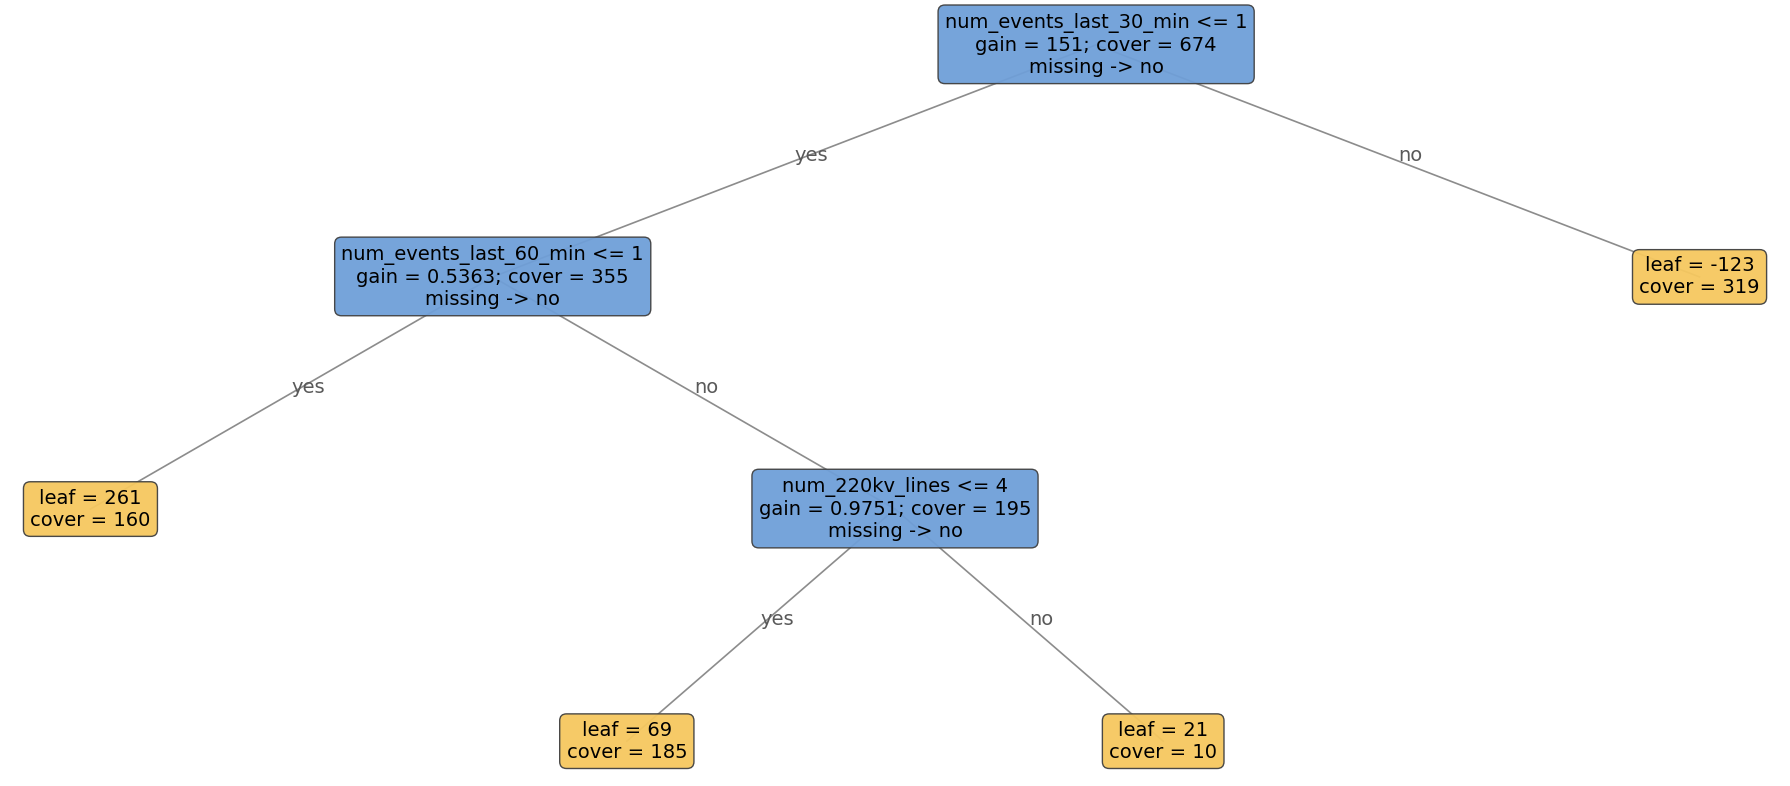

Saved rank 2 tree 1 (total gain=143.66) to /home/aj/phd/nyiso-data/src-bpa/model_outputs/xgboost_when/interpretability/xgboost_best_tree_rank_2_tree_1_bpa.pdf


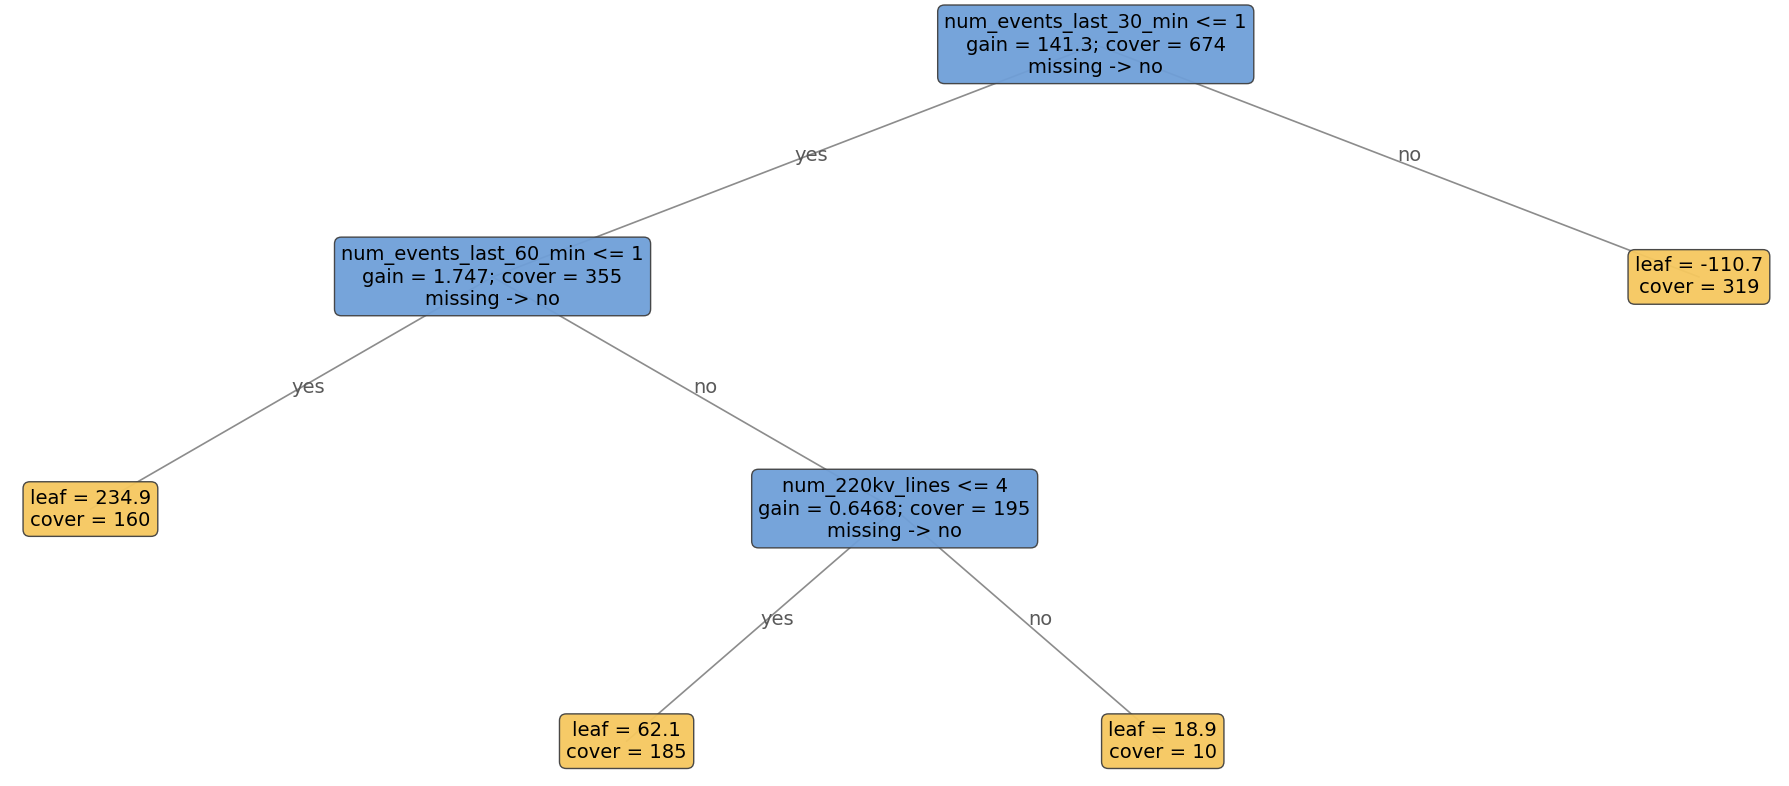

Saved rank 3 tree 2 (total gain=128.865) to /home/aj/phd/nyiso-data/src-bpa/model_outputs/xgboost_when/interpretability/xgboost_best_tree_rank_3_tree_2_bpa.pdf


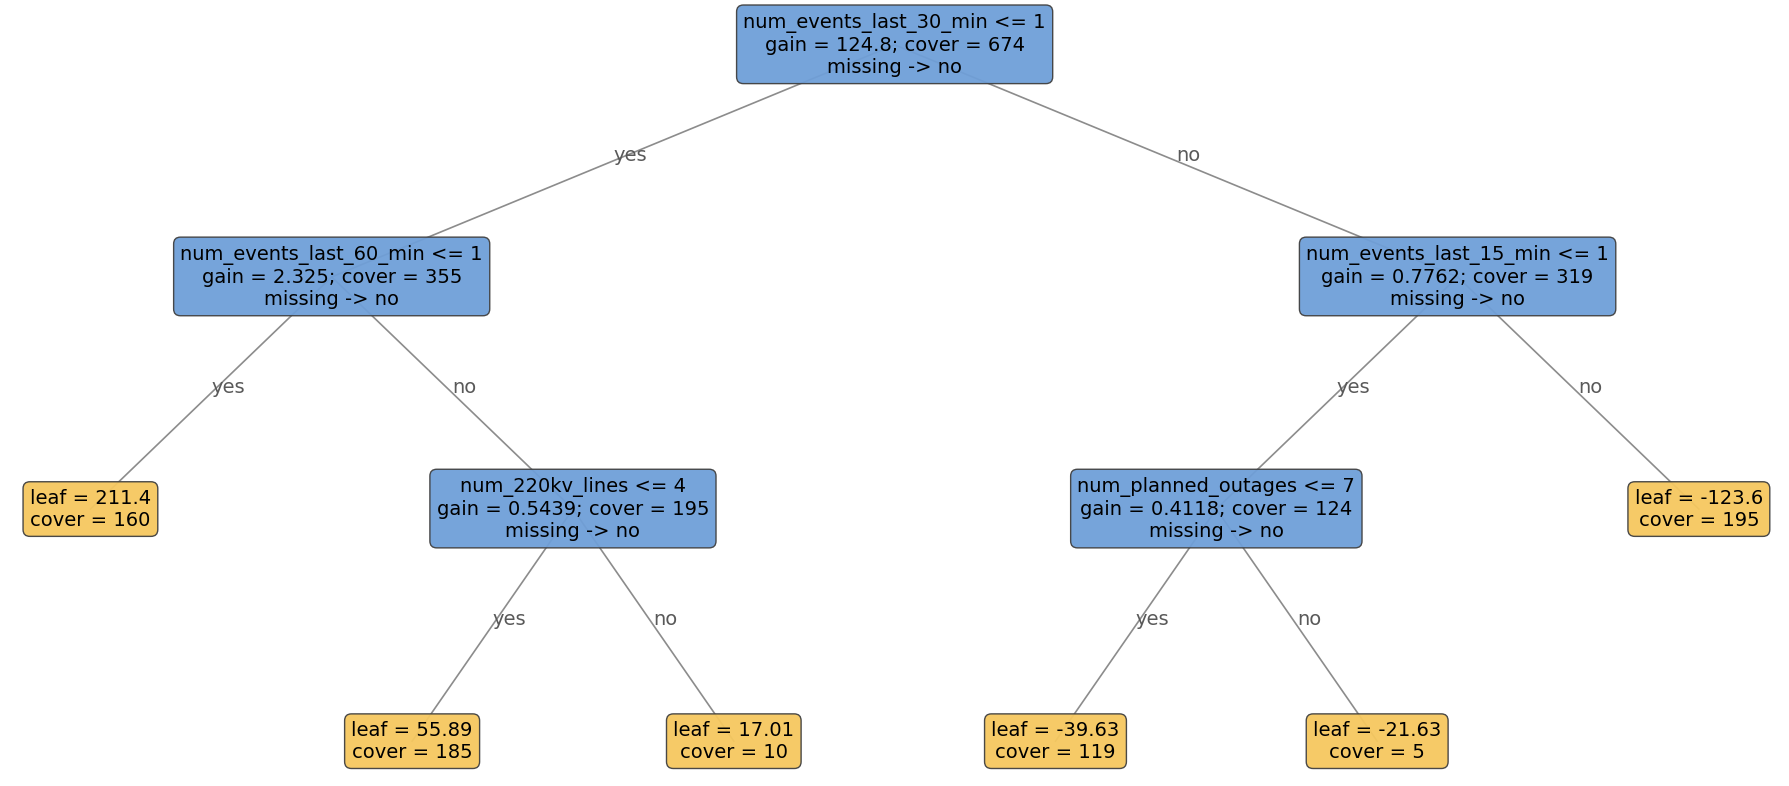

Tree PDFs saved in: /home/aj/phd/nyiso-data/src-bpa/model_outputs/xgboost_when/interpretability


In [16]:
when_tree_table = when_booster.trees_to_dataframe()
when_tree_gain_ranking = (
    when_tree_table.loc[when_tree_table["Feature"] != "Leaf"]
    .groupby("Tree")["Gain"]
    .sum()
    .sort_values(ascending=False)
)
WHEN_TREE_INDICES = when_tree_gain_ranking.head(3).index.astype(int).tolist()
when_tree_pdf_paths = []

for tree_rank, tree_index in enumerate(WHEN_TREE_INDICES, start=1):
    figure, axis = plt.subplots(figsize=(18, 8))
    plot_xgboost_tree(when_booster, tree_index, ax=axis)
    figure.tight_layout()
    tree_pdf_path = (
        WHEN_INTERPRETABILITY_OUTPUT_DIR
        / f"xgboost_best_tree_rank_{tree_rank}_tree_{tree_index}_bpa.pdf"
    )
    figure.savefig(
        tree_pdf_path,
        dpi=300,
        bbox_inches="tight",
    )
    when_tree_pdf_paths.append(tree_pdf_path)
    print(
        f"Saved rank {tree_rank} tree {tree_index} "
        f"(total gain={when_tree_gain_ranking.loc[tree_index]:.6g}) to "
        f"{tree_pdf_path.resolve()}"
    )
    plt.show()

print(f"Tree PDFs saved in: {WHEN_INTERPRETABILITY_OUTPUT_DIR.resolve()}")

#### SHAP analysis

SHAP values are computed on a reproducible sample of the held-out test fold. Model-output effects are converted from seconds to hours; feature values remain in their original units.

In [17]:
import shap

WHEN_SHAP_SAMPLE_SIZE = min(1000, len(when_X_test))
when_X_shap = when_X_test.sample(
    n=WHEN_SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
).sort_index()

when_shap_explainer = shap.TreeExplainer(when_model)
when_shap_values_seconds = when_shap_explainer(when_X_shap)
when_shap_values_hours = shap.Explanation(
    values=when_shap_values_seconds.values / SECONDS_PER_HOUR,
    base_values=when_shap_values_seconds.base_values / SECONDS_PER_HOUR,
    data=when_shap_values_seconds.data,
    feature_names=when_shap_values_seconds.feature_names,
)

when_shap_importance = (
    pd.DataFrame(
        {
            "feature": when_feature_names,
            "mean_abs_shap_hours": np.abs(when_shap_values_hours.values).mean(axis=0),
        }
    )
    .sort_values("mean_abs_shap_hours", ascending=False)
    .reset_index(drop=True)
)
when_shap_importance.to_csv(
    WHEN_INTERPRETABILITY_OUTPUT_DIR / "shap_feature_importance.csv",
    index=False,
)

display(when_shap_importance.head(20))

,feature,mean_abs_shap_hours
0,num_events_last_30_min,0.310139
1,num_events_last_60_min,0.137989
2,num_events_last_15_min,0.066503
3,node_degree_std,0.006666
4,num_events,0.005990
5,num_planned_outages,0.005964
6,node_degree_mean,0.005326
7,node_degree_min,0.004682
8,last_planned_node_degree_mean,0.004014
9,num_500kv_lines,0.002807


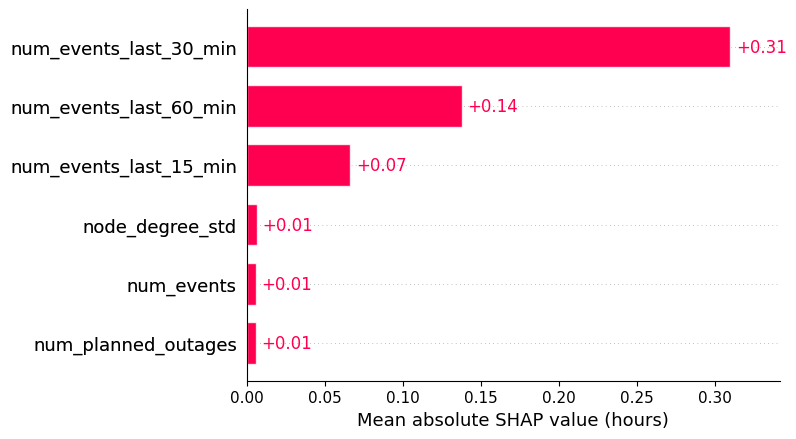

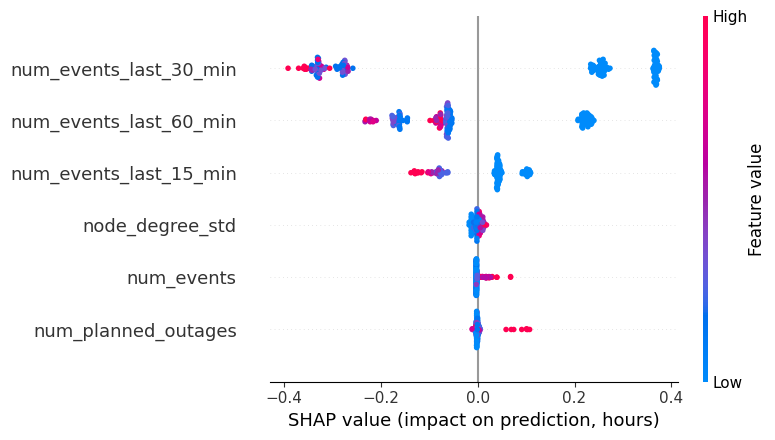

In [18]:
WHEN_SHAP_TOP_FEATURES = 6
when_shap_top_feature_names = when_shap_importance.head(WHEN_SHAP_TOP_FEATURES)[
    "feature"
].tolist()
when_shap_feature_names = list(when_shap_values_hours.feature_names)
when_shap_top_feature_indices = [
    when_shap_feature_names.index(feature) for feature in when_shap_top_feature_names
]
when_shap_top_values_hours = when_shap_values_hours[:, when_shap_top_feature_indices]

figure, axis = plt.subplots(figsize=(8, 4.5))
shap.plots.bar(
    when_shap_top_values_hours,
    max_display=WHEN_SHAP_TOP_FEATURES,
    ax=axis,
    show=False,
)
axis.set_xlabel("Mean absolute SHAP value (hours)")
# axis.set_title("WHEN model global SHAP feature importance")
figure.tight_layout()
figure.savefig(
    WHEN_INTERPRETABILITY_OUTPUT_DIR / "shap_feature_importance_bpa.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

shap.plots.beeswarm(
    when_shap_top_values_hours,
    max_display=WHEN_SHAP_TOP_FEATURES,
    plot_size=(8, 4.5),
    show=False,
)
beeswarm_figure = plt.gcf()
beeswarm_axis = plt.gca()
beeswarm_axis.set_xlabel("SHAP value (impact on prediction, hours)")
# beeswarm_axis.set_title("WHEN model SHAP value distribution")
beeswarm_figure.tight_layout()
beeswarm_figure.savefig(
    WHEN_INTERPRETABILITY_OUTPUT_DIR / "shap_beeswarm_bpa.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

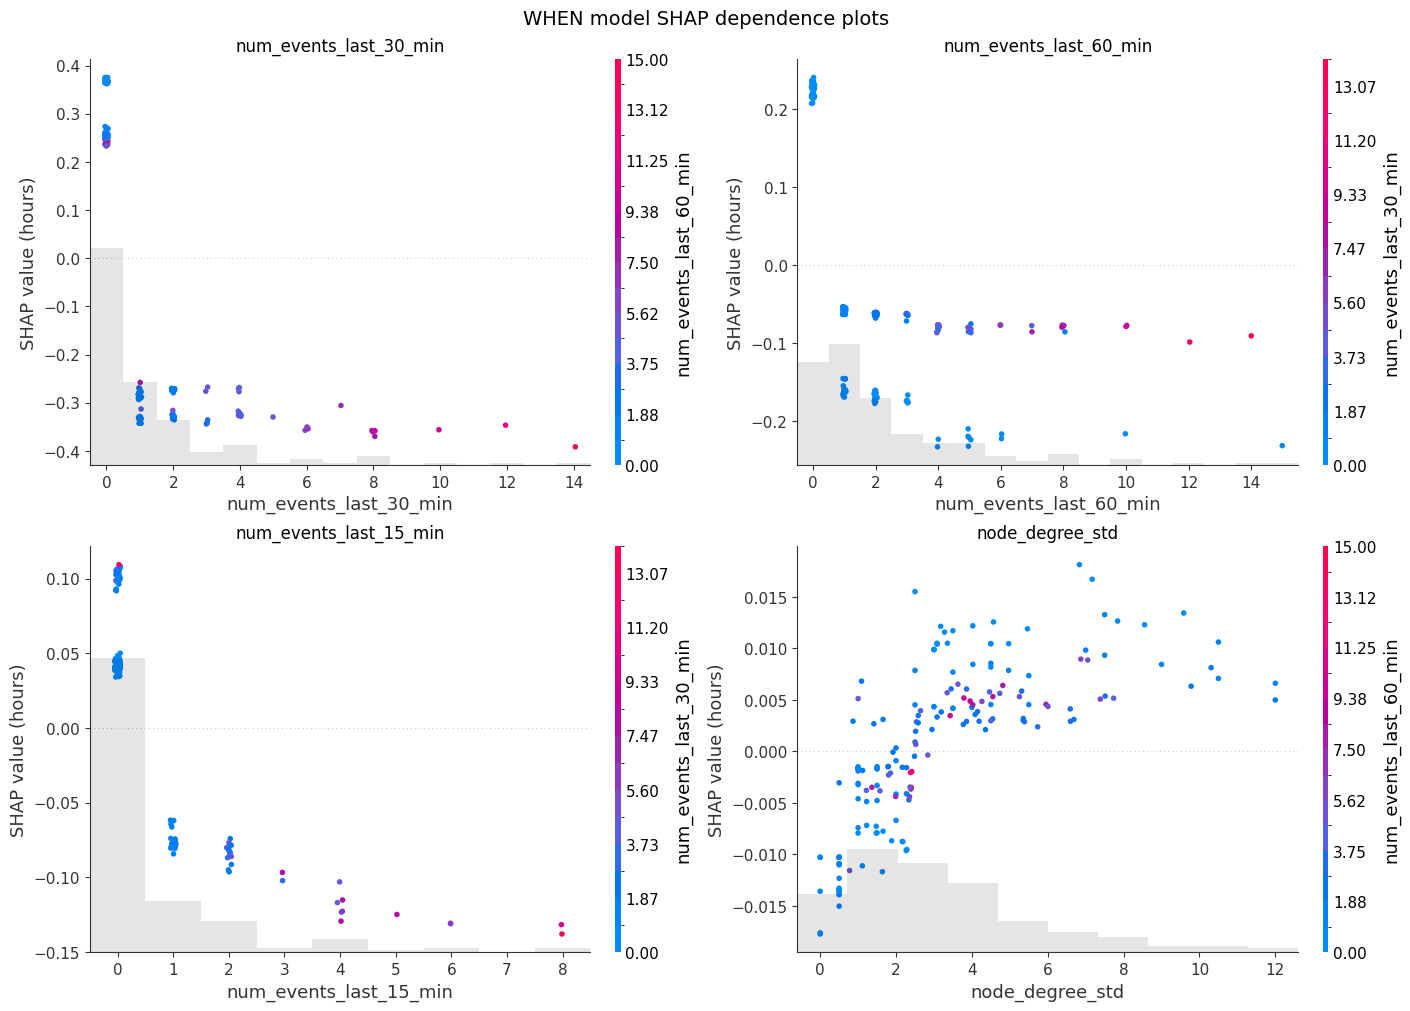

In [19]:
WHEN_DEPENDENCE_FEATURE_COUNT = 4
when_top_features = when_shap_importance.head(WHEN_DEPENDENCE_FEATURE_COUNT)[
    "feature"
].tolist()

dependence_figure, dependence_axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
    constrained_layout=True,
)
for feature_name, axis in zip(when_top_features, dependence_axes.flat):
    shap.plots.scatter(
        when_shap_values_hours[:, feature_name],
        color=when_shap_values_hours,
        ax=axis,
        show=False,
    )
    axis.set_ylabel("SHAP value (hours)")
    axis.set_title(feature_name)
dependence_figure.suptitle("WHEN model SHAP dependence plots", fontsize=14)
dependence_figure.savefig(
    WHEN_INTERPRETABILITY_OUTPUT_DIR / "shap_dependence_top_features_bpa.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Local explanation of the largest test error

,actual_hours,predicted_hours,absolute_error_hours,dataset_index
0,1.566667,1.185071,0.381596,519


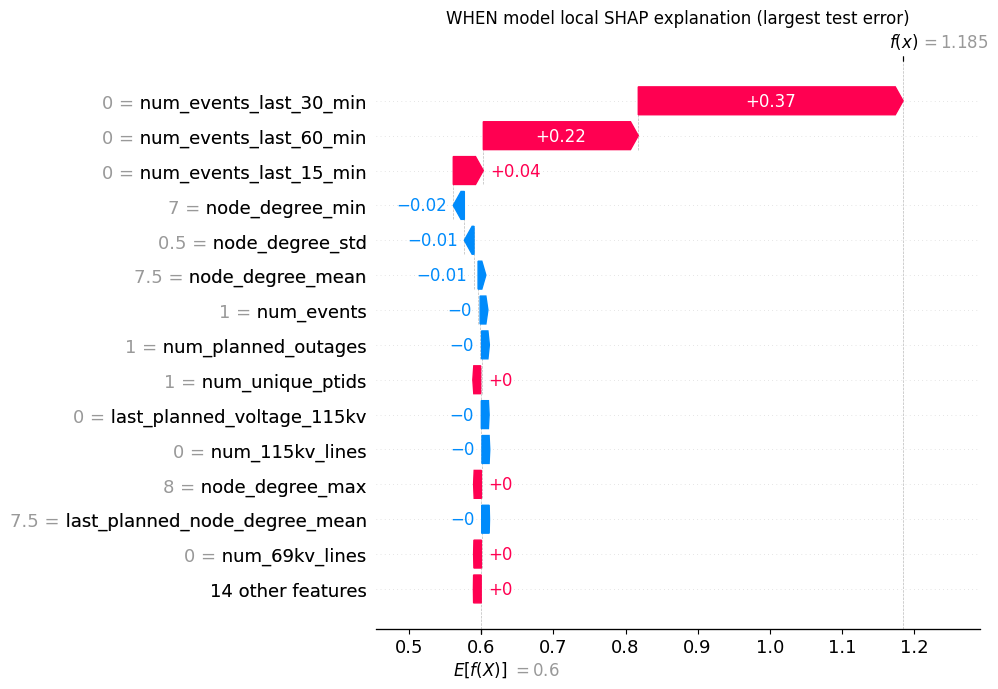

In [20]:
when_test_predictions = when_model.predict(when_X_test)
when_test_absolute_errors = np.abs(when_y_test.to_numpy() - when_test_predictions)
when_local_position = int(np.argmax(when_test_absolute_errors))
when_X_local = when_X_test.iloc[[when_local_position]]
when_local_shap_seconds = when_shap_explainer(when_X_local)
when_local_shap_hours = shap.Explanation(
    values=when_local_shap_seconds.values / SECONDS_PER_HOUR,
    base_values=when_local_shap_seconds.base_values / SECONDS_PER_HOUR,
    data=when_local_shap_seconds.data,
    feature_names=when_local_shap_seconds.feature_names,
)

when_local_summary = pd.DataFrame(
    {
        "actual_hours": [when_y_test.iloc[when_local_position] / SECONDS_PER_HOUR],
        "predicted_hours": [
            when_test_predictions[when_local_position] / SECONDS_PER_HOUR
        ],
        "absolute_error_hours": [
            when_test_absolute_errors[when_local_position] / SECONDS_PER_HOUR
        ],
        "dataset_index": [when_X_local.index[0]],
    }
)
display(when_local_summary)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(when_local_shap_hours[0], max_display=15, show=False)
waterfall_figure = plt.gcf()
waterfall_figure.set_size_inches(10, 7)
plt.title("WHEN model local SHAP explanation (largest test error)")
waterfall_figure.tight_layout()
waterfall_figure.savefig(
    WHEN_INTERPRETABILITY_OUTPUT_DIR / "shap_waterfall_largest_error_bpa.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()